In [1]:
import time
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from imutils import paths
import numpy as np
import argparse
import random
import os
import matplotlib.pyplot as plt
import csv
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

In [2]:
class LeNet:
    @staticmethod
    def build(width, height, depth, classes):
        # Initialize the model
        model = Sequential()
        inputShape = (height, width, depth)

        # First set of CONV => RELU => POOL layers
        model.add(Conv2D(20, (5, 5), padding="same", input_shape=inputShape))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
        
        # Add dropout after the first pooling layer
        model.add(Dropout(0.25))

        # Second set of CONV => RELU => POOL layers
        model.add(Conv2D(50, (5, 5), padding="same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
        
        # Add dropout after the second pooling layer
        model.add(Dropout(0.25))

        # First set of FC => RELU layers
        model.add(Flatten())
        model.add(Dense(500))
        model.add(Activation("relu"))

        # Add dropout before the classification layer
        model.add(Dropout(0.5))
        
        # Second set of FC => RELU layers
        model.add(Flatten())
        model.add(Dense(500))
        model.add(Activation("relu"))

        # Add dropout before the final classification layer
        model.add(Dropout(0.5))

        # Softmax classifier
        model.add(Dense(classes))
        model.add(Activation("softmax"))

        # Return the constructed network architecture
        return model

In [3]:
dataset = 'C:/Users/hugo-/Desktop/images2/'
# initialize the data and labels
print("[INFO] loading images...")
data = []
labels = []

# grab the image paths and randomly shuffle them
imagePaths = sorted(list(paths.list_images(dataset)))
random.seed(42)
random.shuffle(imagePaths)

# loop over the input images
for imagePath in imagePaths:
    # load the image, pre-process it, and store it in the data list
    image = cv2.imread(imagePath, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (36, 36))
    image = img_to_array(image)
    data.append(image)
    
    # Get the directory name that contains the image
    label = os.path.basename(os.path.dirname(imagePath))
    print(label)
    
    if label == "forward":
        label = 0
    elif label == 'soft_left':
        label = 1
    elif label == 'hard_left':
        label = 2
    elif label == 'spin_left':
        label = 3
    elif label == 'soft_right':
        label = 4
    elif label == 'hard_right':
        label = 5
    elif label == 'spin_right':
        label = 6
    else:
        label = 7
    
    labels.append(label)

print(labels)

[INFO] loading images...
hard_right
spin_left
hard_left
soft_left
spin_right
hard_left
hard_left
soft_right
spin_left
spin_right
spin_right
spin_left
spin_left
hard_right
soft_right
spin_right
spin_left
spin_right
spin_right
spin_left
hard_right
spin_right
spin_left
hard_right
soft_right
spin_right
forward
hard_left
hard_left
spin_left
spin_left
spin_left
spin_right
hard_left
spin_left
spin_left
hard_left
soft_left
lost_line
hard_left
spin_right
lost_line
soft_right
hard_left
spin_left
spin_right
spin_left
lost_line
soft_left
spin_right
soft_left
spin_right
hard_right
spin_left
soft_left
hard_left
spin_right
hard_left
lost_line
spin_right
hard_right
hard_right
hard_left
lost_line
spin_right
spin_right
hard_right
forward
spin_right
spin_right
spin_left
spin_left
hard_left
lost_line
hard_right
spin_right
spin_left
hard_right
soft_left
spin_left
spin_left
hard_right
spin_left
spin_right
forward
hard_right
hard_left
spin_left
forward
spin_right
spin_right
spin_left
spin_right
hard_right
sp

spin_right
hard_left
spin_left
spin_left
soft_right
hard_left
soft_left
spin_left
soft_right
soft_left
spin_left
spin_left
spin_left
hard_left
lost_line
forward
soft_right
soft_right
soft_right
lost_line
hard_left
hard_left
forward
hard_left
spin_left
lost_line
lost_line
soft_left
spin_left
forward
soft_left
forward
soft_right
spin_left
spin_left
hard_left
forward
spin_left
spin_right
spin_left
lost_line
spin_right
spin_right
forward
lost_line
lost_line
spin_right
spin_left
hard_right
spin_left
hard_right
hard_right
spin_left
hard_left
hard_right
hard_right
spin_left
hard_right
soft_left
hard_left
spin_left
soft_left
lost_line
lost_line
hard_right
soft_left
spin_left
forward
hard_left
forward
hard_left
hard_right
soft_left
hard_left
spin_left
spin_right
spin_left
spin_right
hard_right
forward
hard_right
hard_right
forward
spin_right
spin_left
spin_left
spin_right
spin_left
spin_left
hard_left
hard_left
spin_left
spin_right
spin_left
hard_left
spin_left
spin_left
spin_left
forward
soft_

spin_right
hard_right
spin_left
forward
hard_left
spin_left
hard_right
spin_left
lost_line
spin_left
spin_left
spin_right
hard_right
spin_left
hard_left
lost_line
hard_left
spin_left
soft_right
spin_right
forward
spin_right
hard_right
spin_left
lost_line
spin_right
lost_line
hard_left
lost_line
hard_left
spin_right
lost_line
spin_right
hard_right
hard_left
spin_right
lost_line
soft_left
spin_left
hard_left
spin_right
spin_right
forward
spin_right
spin_right
hard_right
spin_left
soft_left
hard_right
soft_left
spin_right
spin_left
spin_left
spin_left
hard_right
spin_left
forward
spin_left
soft_right
hard_right
hard_right
hard_left
forward
forward
soft_left
spin_left
hard_left
spin_left
spin_right
spin_left
hard_left
spin_right
hard_left
hard_right
hard_right
hard_right
spin_right
forward
hard_left
spin_left
[5, 3, 2, 1, 6, 2, 2, 4, 3, 6, 6, 3, 3, 5, 4, 6, 3, 6, 6, 3, 5, 6, 3, 5, 4, 6, 0, 2, 2, 3, 3, 3, 6, 2, 3, 3, 2, 1, 7, 2, 6, 7, 4, 2, 3, 6, 3, 7, 1, 6, 1, 6, 5, 3, 1, 2, 6, 2, 7, 6, 5,

In [4]:
# scale the raw pixel intensities to the range [0, 1]
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)
 
# partition the data into training and testing splits using 75% of
# the data for training and the remaining 25% for testing
(trainX, testX, trainY, testY) = train_test_split(data,
    labels, test_size=0.25, random_state=42)
# convert the labels from integers to vectors
trainY = to_categorical(trainY, num_classes=8)
testY = to_categorical(testY, num_classes=8)

In [5]:
# initialize the number of epochs to train for, initial learning rate,
# and batch size
EPOCHS = 100
INIT_LR = 1e-3
BS = 32
# initialize the model
print("[INFO] compiling model...")
model = LeNet.build(width=36, height=36, depth=1, classes=8)
opt = Adam(lr=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss="binary_crossentropy", optimizer=opt,
    metrics=["accuracy"])
 
# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# Train the model
H = model.fit(trainX, trainY, validation_data=(testX, testY), batch_size=BS, epochs=EPOCHS, callbacks=[early_stopping])
 
# save the model to disk
print("[INFO] serializing network...")
model.save("model")

[INFO] compiling model...
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Train on 1365 samples, validate on 456 samples
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/100
1365/1365 [==============================] - 2s 1ms/sample - loss: 0.3061 - acc: 0.8855 - val_loss: 0.2182 - val_acc: 0.9057
Epoch 2/100
1365/1365 [==============================] - 1s 1ms/sample - loss: 0.2160 - acc: 0.9100 - val_loss: 0.1862 - val_acc: 0.9178
Epoch 3/100
1365/1365 [==============================] - 2s 1ms/sample - loss: 0.1834 - acc: 0.9258 - val_loss: 0.1593 - val_acc: 0.9339
Epoch 4/100
1365/1365 [==============================] - 2s 1ms/sample - loss: 0.1596 - acc: 0.9354 - val_loss: 0.1412 - val_acc: 0.9389
Epoch 5/100
1365/1365 [==============================] - 2s 1ms/sample - loss: 0.1444 - acc: 0.9429 - val_loss: 0.1393 - val_acc: 0.9452
Epoch 6/100
1365/1365 [=======

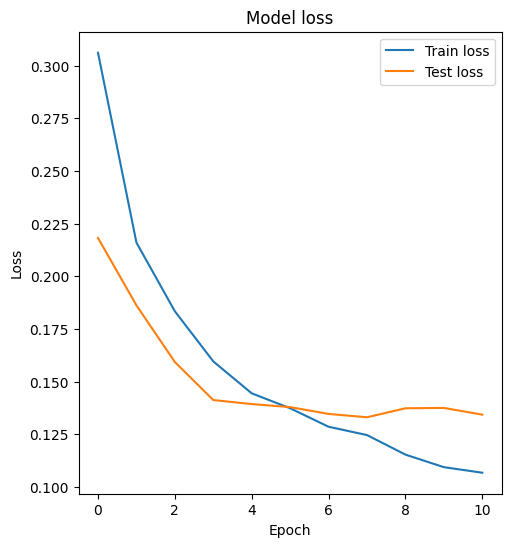

In [6]:
# Plot training & validation loss values
plt.figure(figsize=(12, 6))

# Plot the training loss
plt.subplot(1, 2, 1)
plt.plot(H.history['loss'], label='Train loss')
plt.plot(H.history['val_loss'], label='Test loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

[INFO] generating predictions...


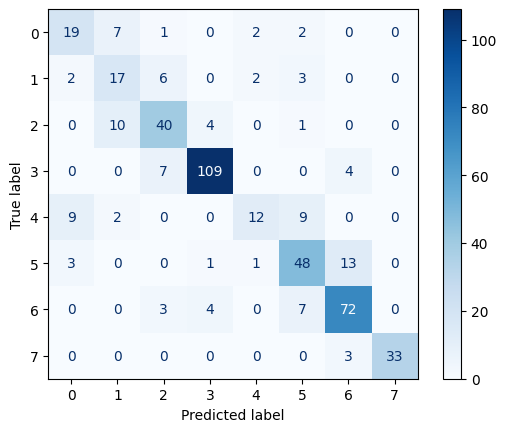

In [7]:
# [INFO] Generate predictions for the test set
print("[INFO] generating predictions...")
predictions = model.predict(testX, batch_size=BS)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(testY, axis=1)  # True labels for comparison

# Generate the confusion matrix comparing true labels with predicted labels
cm = confusion_matrix(true_classes, predicted_classes)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)  # Use the 'Blues' colormap for a clearer visual representation

# Display the plot
plt.show()

In [8]:
# To calculate precision (for binary classification)
precision = cm[0,0] / (cm[0,0] + cm[0,1])  # Assuming binary classification

# Or use sklearn's precision_score for binary or multiclass classification
precision = precision_score(true_classes, predicted_classes, average='macro')  # 'macro' for multiclass
accuracy = accuracy_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes, average='macro')
f1 = f1_score(true_classes, predicted_classes, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7675
Precision: 0.7310
Recall: 0.7089
F1-Score: 0.7125


In [7]:
# save the model to disk
model.save("image_model8.h5")